In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parents[1]
sys.path.insert(0, str(project_root))

In [2]:
import coviar
import os
import kagglehub
import shutil
from pathlib import Path
import json
import csv
import torch
from torch.utils.data import DataLoader
from zipfile import ZipFile
from modules.tokenization_clip import SimpleTokenizer as ClipTokenizer
from dataloaders.dataloader_msrvtt_retrieval import MSRVTT_DataLoader, MSRVTT_TrainDataLoader
from urllib.request import urlretrieve
from huggingface_hub import snapshot_download
import matplotlib.pyplot as plt

/tmp/clip4clip/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def download_via_hf():
    snapshot_download(
    repo_id="friedrichor/MSR-VTT",
    repo_type="dataset",
    local_dir="/tmp/msrvtt"
    )
    
    zip_output = "/tmp/msrvtt/MSRVTT_Videos.zip"
    videos_output = "/tmp/msrvtt/MSRVTT_Videos"
    
    with ZipFile(zip_output, "r") as z:
        z.extractall(videos_output)
    z.close()
    os.remove(zip_output)
    

def download_official_videos():
    url = 'https://www.robots.ox.ac.uk/~maxbain/frozen-in-time/data/MSRVTT.zip'
    zip_output = '/tmp/msrvtt/videos_official.zip'
    extraction_path = "/tmp/msrvtt"
    urlretrieve(url, zip_output)
    with ZipFile(zip_output, 'r') as zObject:
        zObject.extractall(path=extraction_path)
    zObject.close()
    os.rename(extraction_path+'/msrvtt_data', extraction_path+'/videos_official')
    os.remove(zip_output)


def download_official_captions():
    url =  'https://github.com/ArrowLuo/CLIP4Clip/releases/download/v0.0/msrvtt_data.zip'
    zip_output = '/tmp/msrvtt/captions_official.zip'
    extraction_path = "/tmp/msrvtt"
    urlretrieve(url, zip_output)
    with ZipFile(zip_output, 'r') as zObject:
        zObject.extractall(path=extraction_path)
    zObject.close()
    os.rename(extraction_path+'/msrvtt_data', extraction_path+'/captions_official')
    os.remove(zip_output)

def download_dataset():
    base = Path("/tmp/msrvtt")
    video_dir = base / "videos"
    caption_dir = base / "captions"

    video_dir.mkdir(parents=True, exist_ok=True)
    caption_dir.mkdir(parents=True, exist_ok=True)

    video_path = kagglehub.dataset_download(
        "vishnutheepb/msrvtt",
        output_dir=str(video_dir)
    )

    caption_path = kagglehub.dataset_download(
        "vishnutheepb/msrvttdatainfo",
        output_dir=str(caption_dir)
    )

    print("Videos:", video_path)
    print("Captions:", caption_path)
    
    
def caption_json_to_csv(input_path, output_path):

    with open(input_path) as jf:
        d = json.load(jf)

    Ed = d['videos']
    df = open(output_path, 'w')
    cw = csv.writer(df)
    c = 0
    for emp in Ed:
        if c == 0:
        # Writing headers of CSV file
            h = emp.keys()
            cw.writerow(h)
            c += 1

    # Writing data of CSV file
        cw.writerow(emp.values())
    df.close()

In [4]:
download_via_hf()

Fetching 12 files: 100%|██████████| 12/12 [00:11<00:00,  1.09it/s]


In [5]:
csv_path = "/tmp/msrvtt/raw_data/MSRVTT_train.9k.csv"
json_path = "/tmp/msrvtt/raw_data/MSRVTT_data.json"
features_path = "/tmp/msrvtt/MSRVTT_Videos/video"

In [6]:
tokenizer = ClipTokenizer()
batch_size = 10
n_gpu = 1
num_thread_reader = 1
feature_framerate = 1

In [8]:
train_dataloader = MSRVTT_TrainDataLoader(
            csv_path,
            json_path,
            features_path,
            tokenizer,
            feature_framerate=int(feature_framerate))

for step, batch in enumerate(train_dataloader):
    input_ids, input_mask, segment_ids, video, video_mask = batch
    break

print(video[0,1,0].shape)

video path:/tmp/msrvtt/MSRVTT_Videos/video/video0.mp4
(3, 224, 224)


In [9]:
print(input_ids.shape)
print(input_mask.shape)
print(video.shape)
print(video_mask.shape)
print(segment_ids.shape)
print(input_mask)

(1, 30)
(1, 30)
(1, 100, 1, 3, 224, 224)
(1, 100)
(1, 30)
[[1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


In [10]:
from compressed_domain.dataloader.msrvtt_compressed_dataloader import MSRVTT_TrainCompressedDataLoader
compressed_train_loader = MSRVTT_TrainCompressedDataLoader(
            csv_path,
            json_path,
            features_path,
            tokenizer,
            feature_framerate=int(feature_framerate))

for step, batch in enumerate(compressed_train_loader):
    pairs_text, pairs_mask, pairs_segment, video, iframe, mv, residual, video_mask = batch
    break

In [23]:
print(pairs_text.shape)
print(pairs_mask.shape)
print(pairs_segment.shape)
print(video.shape)
print(iframe.shape)
print(mv.shape)
print(residual.shape)
print(video_mask.shape)

print(pairs_text)
print(pairs_mask)
print(pairs_segment)

print(mv)

# print(video[0,1,0].shape)
# print(residual[0,1,0])

(1, 30)
(1, 30)
(1, 30)
(1, 100, 1, 3, 224, 224)
(1, 100, 1, 3, 224, 224)
(1, 100, 1, 2, 224, 224)
(1, 100, 1, 3, 224, 224)
(1, 100)
[[49406  2149  4161   320  1615  1136   518  1759 49407     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0]]
[[1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
[[[[[[0. 0. 0. ... 0. 0. 0.]
     [0. 0. 0. ... 0. 0. 0.]
     [0. 0. 0. ... 0. 0. 0.]
     ...
     [0. 0. 0. ... 0. 0. 0.]
     [0. 0. 0. ... 0. 0. 0.]
     [0. 0. 0. ... 0. 0. 0.]]

    [[0. 0. 0. ... 0. 0. 0.]
     [0. 0. 0. ... 0. 0. 0.]
     [0. 0. 0. ... 0. 0. 0.]
     ...
     [0. 0. 0. ... 0. 0. 0.]
     [0. 0. 0. ... 0. 0. 0.]
     [0. 0. 0. ... 0. 0. 0.]]]]



  [[[[0. 0. 0. ... 0. 0. 0.]
     [0. 0. 0. ... 0. 0. 0.]
     [0. 0. 0. ... 0. 0. 0.]
     ...
     [0. 0. 0. ... 0. 0. 0.]
     [0. 0. 0. ... 0. 0. 0.]
     [0. 0. 0. ... 0. 0

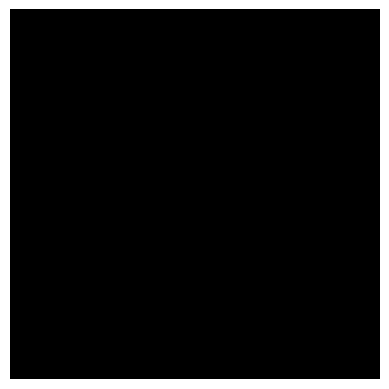

In [14]:
plt.imshow(residual[0,1,0].transpose((1,2,0)))
plt.axis("off")
plt.show()